# Extract single segmentation — PIDNet

This notebook follows the same preprocessing convention as the mixed-loader benchmark.

- SegFormer / Mask2Former use `input_source: raw`, i.e. RGB tensors in `[0,1]`, and keep the HuggingFace processor path.
- DeepLabV3+ / PIDNet / DDRNet use `input_source: repo`, i.e. RGB tensors normalized with ImageNet mean/std before inference, and use `input_norm: none` inside the adapter.

The model is selected entirely from the YAML file.


In [1]:
import os
import sys
import json
from pathlib import Path
from typing import Dict, Optional, Tuple, List

import yaml
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torchvision.transforms as transforms

# ==========================================================
# External repository paths
# Same logic as the mixed-loader benchmark notebook.
# Adjust these paths only if your local folders are different.
# ==========================================================

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

for p in [
    "/home/ace/Downloads",
    "/home/ace/Downloads/PIDNet",
    "/home/ace/Downloads/pytorch-semseg",
    "/home/ace/Downloads/DeepLabV3PlusPytorch",
    "/home/ace/Downloads/DDRNet",
    "/home/ace/Downloads/DDRNet/segmentation",
]:
    if p not in sys.path:
        sys.path.append(p)

from benchmark_models_mixed_loader import (
    build_adapter_from_spec,
    resolve_model_spec_from_key,
)


/home/ace/miniconda3/envs/Benchmarking_framework_GTAV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------
# Load YAML config
# ---------
CONFIG_PATH = "single_segmentation_config_mixed_pidnet.yaml"  # change if needed

with open(CONFIG_PATH, "r") as f:
    CFG = yaml.safe_load(f)

CFG


{'data_dir': '/home/ace/Downloads/Dataset',
 'save_dir': './single_segmentation_outputs_mixed_pidnet',
 'device': 'cuda',
 'selection': {'image_name': None,
  'location_id': '878',
  'illumination': 'Day',
  'weather': 'EXTRASUNNY',
  'pick_index': 0},
 'model': {'key': 'pidnet_m_local',
  'name': 'PIDNet-M',
  'type': 'pidnet',
  'arch': 'pidnet_m',
  'checkpoint_path': '/home/ace/Downloads/models_weights/PIDNet_M_Cityscapes_val.pt',
  'input_source': 'repo',
  'input_norm': 'none'},
 'export': {'preview_figsize': [12, 5],
  'preview_dpi': 200,
  'save_png_too': True,
  'save_raw_prediction_npy': True,
  'save_confidence_npy': False}}

In [3]:
# ---------
# Global settings
# ---------
DATA_DIR = CFG["data_dir"]
SAVE_DIR = CFG["save_dir"]
DEVICE = torch.device(CFG.get("device", "cuda" if torch.cuda.is_available() else "cpu"))

SELECTION = CFG["selection"]
MODEL_CFG = CFG["model"]
EXPORT_CFG = CFG.get("export", {})

os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE


device(type='cuda')

In [4]:
# ---------
# Palette and helpers
# ---------
CITYSCAPES_PALETTE_19 = np.array([
    (128,  64, 128),  # road
    (244,  35, 232),  # sidewalk
    ( 70,  70,  70),  # building
    (102, 102, 156),  # wall
    (190, 153, 153),  # fence
    (153, 153, 153),  # pole
    (250, 170,  30),  # traffic light
    (220, 220,   0),  # traffic sign
    (107, 142,  35),  # vegetation
    (152, 251, 152),  # terrain
    ( 70, 130, 180),  # sky
    (220,  20,  60),  # person
    (255,   0,   0),  # rider
    (  0,   0, 142),  # car
    (  0,   0,  70),  # truck
    (  0,  60, 100),  # bus
    (  0,  80, 100),  # train
    (  0,   0, 230),  # motorcycle
    (119,  11,  32),  # bicycle
], dtype=np.uint8)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def decode_cityscapes_mask(mask_hw: np.ndarray) -> np.ndarray:
    h, w = mask_hw.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    valid = (mask_hw >= 0) & (mask_hw < len(CITYSCAPES_PALETTE_19))
    out[valid] = CITYSCAPES_PALETTE_19[mask_hw[valid]]
    return out

def tensor_to_uint8_img(x: torch.Tensor) -> np.ndarray:
    return (x.detach().cpu().clamp(0, 1).numpy().transpose(1, 2, 0) * 255).astype(np.uint8)

def select_image_path(data_dir: str, selection: Dict) -> str:
    data_dir = Path(data_dir)

    if selection.get("image_name") is not None:
        matches = sorted(data_dir.rglob(selection["image_name"]))
        if len(matches) == 0:
            raise FileNotFoundError(f"image_name not found: {selection['image_name']}")
        return str(matches[selection.get("pick_index", 0)])

    location_id = str(selection["location_id"])
    illumination = selection["illumination"]
    weather = selection["weather"]
    pick_index = int(selection.get("pick_index", 0))

    search_dir = data_dir / illumination

    if not search_dir.exists():
        raise FileNotFoundError(f"Illumination folder not found: {search_dir}")

    candidates = []
    for p in sorted(search_dir.glob("*")):
        if not p.is_file():
            continue
        if not p.name.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        if p.name.startswith(str(location_id)) and illumination in p.name and weather in p.name:
            candidates.append(p)

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No image found for location_id={location_id}, illumination={illumination}, weather={weather}"
        )

    return str(candidates[pick_index])

def make_raw_tensor(pil_img: Image.Image) -> torch.Tensor:
    return transforms.ToTensor()(pil_img)

def make_repo_tensor(pil_img: Image.Image) -> torch.Tensor:
    repo_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return repo_transform(pil_img)

def prepare_model_input(pil_img: Image.Image, input_source: str) -> torch.Tensor:
    input_source = str(input_source).lower()

    if input_source == "raw":
        return make_raw_tensor(pil_img)

    if input_source in {"repo", "repo_imagenet", "imagenet"}:
        return make_repo_tensor(pil_img)

    raise ValueError(f"Unsupported input_source: {input_source}")


In [5]:
# ---------
# Model adapter loading
# ---------
# This notebook does NOT re-implement SegFormer/Mask2Former/DeepLab/PIDNet/DDRNet.
# It uses the same adapter registry and checkpoint-loading logic used by the mixed-loader benchmark.

def build_model_adapter(model_cfg: Dict, device: torch.device):
    if "key" in model_cfg:
        spec = resolve_model_spec_from_key(model_cfg["key"])
        # YAML values override registry defaults.
        spec.update({k: v for k, v in model_cfg.items() if k != "key"})
        return build_adapter_from_spec(spec, device)

    return build_adapter_from_spec(dict(model_cfg), device)


In [6]:
# ---------
# Select image and run model
# ---------
image_path = select_image_path(DATA_DIR, SELECTION)
print("Selected image:", image_path)

adapter = build_model_adapter(MODEL_CFG, DEVICE)
print("Loaded model:", adapter.name)

input_source = MODEL_CFG.get("input_source", "raw")
print("Input source:", input_source)

pil_img = Image.open(image_path).convert("RGB")

# RGB image for visualization is always raw [0,1].
raw_t = make_raw_tensor(pil_img)
rgb_np = tensor_to_uint8_img(raw_t)

# Model input depends on the YAML:
# - raw  -> SegFormer/Mask2Former with HF processor path
# - repo -> DeepLab/PIDNet/DDRNet, already ImageNet-normalized, input_norm=none
img_t = prepare_model_input(pil_img, input_source).unsqueeze(0).to(DEVICE)

pred, conf = adapter.predict(img_t)

pred_np = pred[0].detach().cpu().numpy().astype(np.int32)
conf_np = conf[0].detach().cpu().numpy()

seg_rgb = decode_cityscapes_mask(pred_np)

print("Prediction shape:", pred_np.shape)
print("Confidence mean:", float(conf_np.mean()))


Selected image: /home/ace/Downloads/Dataset/Day/878_Day_EXTRASUNNY.png
Loaded model: PIDNet-M
Input source: repo
Prediction shape: (950, 1916)
Confidence mean: 0.8005242347717285


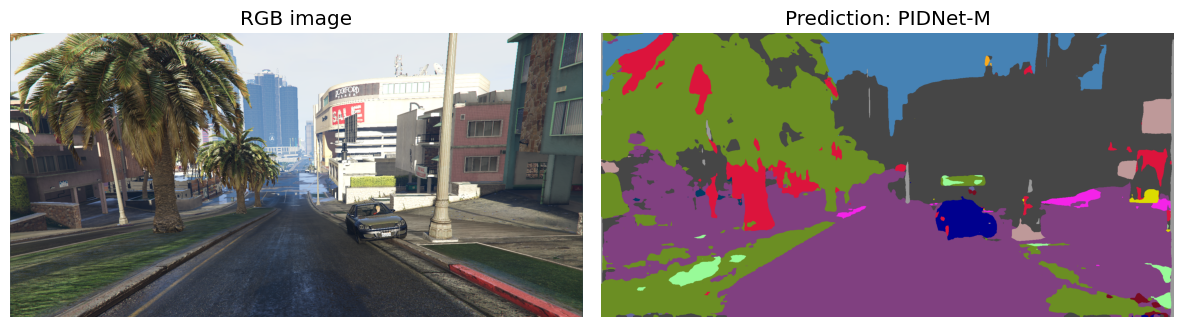

In [7]:
# ---------
# Preview in notebook
# ---------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(rgb_np)
ax1.set_title("RGB image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(seg_rgb)
ax2.set_title(f"Prediction: {adapter.name}")
ax2.axis("off")

fig.tight_layout()
plt.show()
plt.close(fig)


In [8]:
# ---------
# Export outputs
# ---------
stem = Path(image_path).stem
model_slug = adapter.name.replace(" ", "_").replace("/", "_").replace("+", "plus")

save_mask_png = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__segmentation.png")
save_preview_pdf = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__preview.pdf")
save_preview_png = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__preview.png")

Image.fromarray(seg_rgb).save(save_mask_png)

preview_figsize = tuple(EXPORT_CFG.get("preview_figsize", [12, 5]))
preview_dpi = int(EXPORT_CFG.get("preview_dpi", 200))
save_png_too = bool(EXPORT_CFG.get("save_png_too", True))

fig = plt.figure(figsize=preview_figsize)

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(rgb_np)
ax1.set_title("RGB image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(seg_rgb)
ax2.set_title(f"Prediction: {adapter.name}")
ax2.axis("off")

fig.tight_layout()
fig.savefig(save_preview_pdf, bbox_inches="tight")

if save_png_too:
    fig.savefig(save_preview_png, dpi=preview_dpi, bbox_inches="tight")

plt.close(fig)

if EXPORT_CFG.get("save_raw_prediction_npy", True):
    np.save(os.path.join(SAVE_DIR, f"{stem}__{model_slug}__prediction.npy"), pred_np)

if EXPORT_CFG.get("save_confidence_npy", False):
    np.save(os.path.join(SAVE_DIR, f"{stem}__{model_slug}__confidence.npy"), conf_np)

summary = {
    "image_path": image_path,
    "model_name": adapter.name,
    "model_key": MODEL_CFG.get("key"),
    "model_type": MODEL_CFG.get("type"),
    "model_id": MODEL_CFG.get("model_id"),
    "checkpoint_path": MODEL_CFG.get("checkpoint_path"),
    "input_source": MODEL_CFG.get("input_source"),
    "input_norm": MODEL_CFG.get("input_norm"),
    "device": str(DEVICE),
    "prediction_shape": list(pred_np.shape),
    "confidence_mean": float(conf_np.mean()),
    "outputs": {
        "segmentation_png": save_mask_png,
        "preview_pdf": save_preview_pdf,
        "preview_png": save_preview_png if save_png_too else None,
    }
}

summary_path = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved mask:", save_mask_png)
print("Saved preview PDF:", save_preview_pdf)
if save_png_too:
    print("Saved preview PNG:", save_preview_png)
print("Saved summary:", summary_path)

summary


Saved mask: ./single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__segmentation.png
Saved preview PDF: ./single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__preview.pdf
Saved preview PNG: ./single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__preview.png
Saved summary: ./single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__summary.json


{'image_path': '/home/ace/Downloads/Dataset/Day/878_Day_EXTRASUNNY.png',
 'model_name': 'PIDNet-M',
 'model_key': 'pidnet_m_local',
 'model_type': 'pidnet',
 'model_id': None,
 'checkpoint_path': '/home/ace/Downloads/models_weights/PIDNet_M_Cityscapes_val.pt',
 'input_source': 'repo',
 'input_norm': 'none',
 'device': 'cuda',
 'prediction_shape': [950, 1916],
 'confidence_mean': 0.8005242347717285,
 'outputs': {'segmentation_png': './single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__segmentation.png',
  'preview_pdf': './single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__preview.pdf',
  'preview_png': './single_segmentation_outputs_mixed_pidnet/878_Day_EXTRASUNNY__PIDNet-M__preview.png'}}